In [1]:
import importlib
import quantum_function
importlib.reload(quantum_function)

from quantum_function import *

In [2]:
Sz_1


Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.5  0.   0.   0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]
 [ 0.   0.   0.  -0.5]]

In [3]:
Sz_2

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.5  0.   0.   0. ]
 [ 0.  -0.5  0.   0. ]
 [ 0.   0.   0.5  0. ]
 [ 0.   0.   0.  -0.5]]

In [4]:
PlusPlus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

In [5]:
gamma = 1   # Atomic decay rate

#Combination plus and minus of the two operators
c_ops =[np.sqrt(gamma) * ((Sz_1+Sz_2)/np.sqrt(2)), np.sqrt(gamma) * ((Sz_1-Sz_2)/np.sqrt(2))]


In [6]:
c_ops[0]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.70710678  0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.         -0.70710678]]

In [7]:
c_ops[1]

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.          0.          0.          0.        ]
 [ 0.          0.70710678  0.          0.        ]
 [ 0.          0.         -0.70710678  0.        ]
 [ 0.          0.          0.          0.        ]]

### Calcoliamo l'azione dei due collapsing operators sullo stato $|++ \rangle$

In [8]:
Jump_plus = (c_ops[0]*PlusPlus).unit()
Jump_plus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [ 0.        ]
 [ 0.        ]
 [-0.70710678]]

Otteniamo lo stato $\dfrac{|11\rangle - |00 \rangle}{\sqrt{2}}$ = $-|\phi_{-}\rangle$, stato di  antisimmetrico

In [9]:
Jump_minus = (c_ops[1]*PlusPlus).unit()
Jump_minus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        ]
 [ 0.70710678]
 [-0.70710678]
 [ 0.        ]]

Otteniamo lo stato $\dfrac{|10\rangle - |01 \rangle}{\sqrt{2}}$ = $-|\psi_{-}\rangle$, stato di Bell antisimmetrico

### Vediamo cosa otteniamo col secondo Jump, partiamo dal caso di primo jump positivo, ossia da $-|\phi_{-}\rangle$

In [10]:
Jump_2_plus_plus = (c_ops[0]*Jump_plus).unit()
Jump_2_plus_plus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

Ottengo $|\psi_{+}\rangle$

In [11]:
Jump_2_plus_minus = (c_ops[1]*Jump_plus)
Jump_2_plus_minus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]]

Qui lo stato nullo!

### Adesso dal primo jump negativo, ossia da $-|\psi_{-}\rangle$

In [12]:
Jump_2_minus_plus = (c_ops[0]*Jump_minus)
Jump_2_minus_plus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [0.]]

Stato nullo anche qui

In [13]:
Jump_2_minus_minus = (c_ops[1]*Jump_minus).unit()
Jump_2_minus_minus

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.70710678]
 [0.70710678]
 [0.        ]]

Analogamente si ottiene $|\psi_{+}\rangle$

In [14]:
# Function that acts as a collapsing operator on a given state

def jump_operator(c_ops, state):
    jump_plus = (c_ops[0]*state)
    
    if jump_plus.norm() != 0:
        jump_plus = jump_plus.unit()

    jump_minus = (c_ops[1]*state)

    if jump_minus.norm() != 0:
        jump_minus = jump_minus.unit()

    return jump_plus, jump_minus

### E così via, dopo il primo jump determino la parità del mio sottospazio e rimango lì, ogni jump alterna versione + e - dello stato di Bell associato alla parità. 
### Se pari ho gli stati $\phi$ se invece dispari gli stati $\psi$

In [15]:
Jump_3_plus_plus = jump_operator(c_ops, Jump_2_plus_plus)
Jump_3_plus_plus

(Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.70710678]
  [ 0.        ]
  [ 0.        ]
  [-0.70710678]],
 Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [0.]])

In [16]:
Jump_3_minus_minus = jump_operator(c_ops, Jump_2_minus_minus)
Jump_3_minus_minus

(Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [0.]],
 Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.        ]
  [ 0.70710678]
  [-0.70710678]
  [ 0.        ]])

In [20]:
#Nuove simulazioni

gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.01*T_1)) # time vector

my_name_states = ["++"]

my_initial_states = [PlusPlus]


#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        options={"keep_runs_results":True, "map":"parallel"} #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:  11.59s. Est. time left: 00:00:01:44
20.0%. Run time:  11.67s. Est. time left: 00:00:00:46
30.0%. Run time:  11.74s. Est. time left: 00:00:00:27
40.0%. Run time:  11.82s. Est. time left: 00:00:00:17
50.0%. Run time:  11.88s. Est. time left: 00:00:00:11
60.0%. Run time:  11.94s. Est. time left: 00:00:00:07
70.0%. Run time:  12.01s. Est. time left: 00:00:00:05
80.0%. Run time:  12.06s. Est. time left: 00:00:00:03
90.0%. Run time:  12.12s. Est. time left: 00:00:00:01
100.0%. Run time:  12.17s. Est. time left: 00:00:00:00
Total run time:  13.25s


In [53]:
# --- parametri (usa i tuoi già definiti)
gamma = 1.0
eta = 0.3               # efficienza esempio
ntraj = 10000
times = np.array(np.arange(0, 5*(1/gamma), 0.01*(1/gamma)))  # come prima

# --- operatori (assumo Sz_1, Sz_2 già definiti nel tuo notebook)
L_plus  = np.sqrt(gamma/2) * (Sz_1 + Sz_2)
L_minus = np.sqrt(gamma/2) * (Sz_1 - Sz_2)

# split monitored / loss (mettendo prima i monitored è cruciale)
monitored_ops = [np.sqrt(eta) * L_plus, np.sqrt(eta) * L_minus]
loss_ops      = [np.sqrt(1.0 - eta) * L_plus, np.sqrt(1.0 - eta) * L_minus]
c_ops = monitored_ops + loss_ops
n_monitored = len(monitored_ops)   # = 2 nel tuo caso

# Options per mcsolve: non salvare gli stati (save memoria) ma tenere i run results
my_options = {"store_states": False, "keep_runs_results": True, "map": "parallel"}

In [54]:
# Esempio per |++>
state = css_2(np.pi/2, phi=0)  # |++> nel tuo codice
result = mcsolve(H_free, state, times,
                    c_ops=c_ops,
                    e_ops=[],     # se non ti servono expect qui, tienilo vuoto per risparmiare memoria
                    ntraj=ntraj,
                    options=my_options
                    )

# --- estrazione raw: col_which e col_times sono liste di lunghezza ntraj
col_which = result.col_which   # es: [[0,1,1,2], [], [1,2], ...]
col_times = result.col_times   # es: [[0.12,0.45,0.90], [], [0.33,1.1], ...]

col_which

10.0%. Run time:   8.46s. Est. time left: 00:00:01:16
20.0%. Run time:  10.72s. Est. time left: 00:00:00:42
30.0%. Run time:  13.31s. Est. time left: 00:00:00:31
40.0%. Run time:  18.62s. Est. time left: 00:00:00:27
50.0%. Run time:  20.91s. Est. time left: 00:00:00:20
60.0%. Run time:  23.31s. Est. time left: 00:00:00:15
70.0%. Run time:  25.64s. Est. time left: 00:00:00:10
80.0%. Run time:  27.88s. Est. time left: 00:00:00:06
90.0%. Run time:  30.11s. Est. time left: 00:00:00:03
100.0%. Run time:  32.37s. Est. time left: 00:00:00:00
Total run time:  33.20s


[[],
 (2, 0, 2),
 (2,),
 (0, 2, 0, 2, 2),
 (2,),
 (3, 1, 1, 3, 1, 3, 1),
 (3, 3, 3, 3, 1),
 (3, 1, 3),
 (3, 1, 1),
 (3, 3, 1, 3, 1),
 (3, 3, 3),
 (1, 3),
 [],
 (3, 1),
 (2,),
 (3, 3, 3, 3),
 (0, 0),
 (1, 3, 3),
 (0, 0),
 (2,),
 (3, 3, 3),
 (3, 1),
 (0,),
 (3, 3, 3),
 (2,),
 (3, 3, 3, 3),
 (0, 0),
 (3, 1, 3, 3),
 [],
 (3,),
 (2, 2),
 (2, 2),
 (3, 1, 3, 1),
 (3, 3, 3, 3, 3, 3),
 (1, 1, 3),
 (1, 3),
 (2, 2),
 (1, 3),
 (3, 1),
 (3, 1),
 (2, 2),
 (3,),
 (3,),
 (2, 2, 2, 2, 2),
 (0,),
 (2, 2, 0),
 (3, 1, 3, 1),
 (3, 1),
 (3, 1),
 (3, 3, 3),
 (1,),
 (0,),
 (0, 0),
 (2, 2, 0),
 (3, 1),
 (3,),
 (3, 3),
 (3, 3),
 (0, 2, 2, 0),
 (3,),
 (2, 2, 0),
 (2, 2, 2, 2),
 (3, 3, 3, 1, 1),
 (3, 3),
 (3, 3),
 (2,),
 (2, 2),
 (0,),
 (3, 1, 3, 3, 1),
 (3, 3),
 (1, 1, 3),
 (2, 0, 2, 2, 2),
 (3, 1),
 (0, 0, 2, 0, 2),
 (2, 2),
 (1, 3),
 (1,),
 (2, 2),
 (3, 1),
 (2,),
 (2, 2, 0, 2, 0, 0),
 (0, 0, 0, 2, 2),
 (3,),
 (2, 2, 0),
 (0, 0, 0, 2),
 (0, 2, 0),
 (0,),
 (0, 0, 2, 2, 2, 0, 2, 2),
 (2, 0, 0, 2),
 [],
 (3,),
 (

In [ ]:
#col_times

In [ ]:
# --- Funzione  per etichettare i jump!
def idx_to_label(idx):
    if idx == 0:
        return '+'
    elif idx == 1:
        return '-'
    else:
        return 'loss'


# --- Statistiche per traiettoria, inizializzo le liste
labels_per_traj = []
events_per_traj = []
detected_counts = []
total_counts = []

# Analizzo i jump per traiettoria con col_which e col_times

for which_list, times_list in zip(col_which, col_times):

    #which_list = list(which_list)
    #times_list = list(times_list)

    #Piazzo le labels
    labels = [idx_to_label(i) for i in which_list]
    labels_per_traj.append(labels)

    #Creo lista di eventi (tempo, label)
    events = list(zip(times_list, labels))
    events_per_traj.append(events)

    #Calcolo i detect totali
    total = len(labels)
    total_counts.append(total)

    #Calcolo i detect monitorati
    detected = sum(1 for lab in labels if lab in ('+','-'))
    detected_counts.append(detected)


# --- DataFrame compatto con le statistiche (una riga per traiettoria)
df_jumps = pd.DataFrame({
    "traj": np.arange(1, ntraj+1),
    "detected_jumps": detected_counts,
    "total_jumps": total_counts,
    "detected_rate": np.array(detected_counts) / times[-1],
    "total_rate": np.array(total_counts) / times[-1],
})
df_jumps.set_index("traj", inplace=True)


# --- controlli e aggregati globali
mean_detected = df_jumps["detected_counts"].mean()
mean_total    = df_jumps["total_counts"].mean()
print(f"Media detected jumps / traj = {mean_detected:.3f}")
print(f"Media total jumps / traj    = {mean_total:.3f}")
print(f"Ratio detected/total ≈ {mean_detected/mean_total if mean_total>0 else np.nan :.3f} (atteso ~ eta = {eta})")

# verifica veloce che la media sia compatibile con eta (tolleranza)
if mean_total > 0:
    rel_err = abs((mean_detected/mean_total) - eta)
    print(f"Errore relativo rispetto a eta: {rel_err:.3e}")

Media detected jumps / traj = 0.750
Media total jumps / traj    = 2.489
Ratio detected/total ≈ 0.301 (atteso ~ eta = 0.3)
Errore relativo rispetto a eta: 1.490e-03


In [16]:
# --- istogramma dei tempi di detected jumps su tutte le traiettorie (per costruire tassi temporali)
#all_detected_times = [t for sub in detected_times_per_traj for t in sub]   # flatten
#hist_counts, hist_bins = np.histogram(all_detected_times, bins=times)  # bins allineati ai tuoi times
# hist_counts[i] = numero di detected jumps nel bin [hist_bins[i], hist_bins[i+1])

# --- esempio: salva i risultati su file (utile per non tenere tutto in memoria)
#df_jumps.to_pickle("jumps_stats.pkl")   # object dtype OK
#np.save("detected_times_all.npy", np.array(all_detected_times, dtype=object))


# --- se vuoi anche una tabella temporale media (timestep-wise) con il rate rilevato:
#rate_detected_per_bin = hist_counts / (ntraj * (hist_bins[1]-hist_bins[0]))  # rate medio per traiettoria per unità di tempo
#df_rate = pd.DataFrame({
    #"t_bin_left": hist_bins[:-1],
    #"t_bin_right": hist_bins[1:],
    #"detected_counts_in_bin": hist_counts,
    #"detected_rate": rate_detected_per_bin
#})

In [56]:
df_jumps

,detected_counts,total_counts,detected_rate,total_rate
traj,,,,
1,0,0,0.000000,0.000000
2,1,3,0.200401,0.601202
3,0,1,0.000000,0.200401
4,2,5,0.400802,1.002004
5,0,1,0.000000,0.200401
...,...,...,...,...
9996,0,1,0.000000,0.200401
9997,3,5,0.601202,1.002004
9998,0,2,0.000000,0.400802


In [50]:
# --- parametri (usa i tuoi già definiti)
gamma = 1.0
eta = 0.3               # efficienza esempio
ntraj = 1000
times = np.array(np.arange(0, 5*(1/gamma), 0.01*(1/gamma)))  # come prima

# --- operatori (assumo Sz_1, Sz_2 già definiti nel tuo notebook)
L_plus  = np.sqrt(gamma/2) * (Sz_1 + Sz_2)
L_minus = np.sqrt(gamma/2) * (Sz_1 - Sz_2)

H_extra = -1j/2 * (1-eta)* (L_plus.dag()*L_plus + L_minus.dag()*L_minus)


monitored_ops = [np.sqrt(eta) * L_plus, np.sqrt(eta) * L_minus]
n_monitored = len(monitored_ops)   # = 2 nel tuo caso

# Options per mcsolve: non salvare gli stati (save memoria) ma tenere i run results
my_options = {"store_states": False, "keep_runs_results": True, "map": "parallel"}

# Esempio per |++>
state = css_2(np.pi/2, phi=0)  # |++> nel tuo codice
result = mcsolve(H_free, state, times,
                    c_ops=monitored_ops,
                    e_ops=[],     # se non ti servono expect qui, tienilo vuoto per risparmiare memoria
                    ntraj=ntraj,
                    options=my_options
                    )

# --- Estrazione raw
col_which = result.col_which   # es: [[0,1,1,2], [], [1,2], ...]

10.0%. Run time:   6.42s. Est. time left: 00:00:00:57
20.0%. Run time:   6.67s. Est. time left: 00:00:00:26
30.0%. Run time:   6.90s. Est. time left: 00:00:00:16
40.0%. Run time:   7.14s. Est. time left: 00:00:00:10
50.0%. Run time:   7.39s. Est. time left: 00:00:00:07
60.0%. Run time:   7.60s. Est. time left: 00:00:00:05
70.0%. Run time:   7.83s. Est. time left: 00:00:00:03
80.0%. Run time:   8.05s. Est. time left: 00:00:00:02
90.0%. Run time:   8.26s. Est. time left: 00:00:00:00
100.0%. Run time:   8.48s. Est. time left: 00:00:00:00
Total run time:   9.34s


In [51]:
# --- Statistiche per traiettoria, inizializzo le liste
labels_per_traj = []
detected_counts = []
total_counts = []

# Analizzo i jump per traiettoria con col_which e col_times

for which_list in col_which:

    #Piazzo le labels
    labels = [idx_to_label(i) for i in which_list]
    labels_per_traj.append(labels)

    #Calcolo i detect totali
    total = len(labels)
    total_counts.append(total)

    #Calcolo i detect monitorati
    detected = sum(1 for lab in labels if lab in ('+','-'))
    detected_counts.append(detected)


# --- DataFrame compatto con le statistiche (una riga per traiettoria)
df_jumps = pd.DataFrame({
    "traj": np.arange(1, ntraj+1),
    "detected_counts": detected_counts,
    "total_counts": total_counts,
    "detected_rate": np.array(detected_counts) / times[-1],
    "total_rate": np.array(total_counts) / times[-1],
})
df_jumps.set_index("traj", inplace=True)


# --- controlli e aggregati globali
mean_detected = df_jumps["detected_counts"].mean()
mean_total    = df_jumps["total_counts"].mean()
mean_rate     = df_jumps["detected_rate"].mean()


print(f"Media detected jumps / traj = {mean_detected:.3f}")
print(f"Media total jumps / traj    = {mean_total:.3f}")
print(f"Mean rate =  {mean_rate:.3f}")

Media detected jumps / traj = 0.713
Media total jumps / traj    = 0.713
Mean rate =  0.143


In [52]:
df_jumps   

,detected_counts,total_counts,detected_rate,total_rate
traj,,,,
1,0,0,0.000000,0.000000
2,0,0,0.000000,0.000000
3,0,0,0.000000,0.000000
4,0,0,0.000000,0.000000
5,1,1,0.200401,0.200401
...,...,...,...,...
996,2,2,0.400802,0.400802
997,1,1,0.200401,0.200401
998,0,0,0.000000,0.000000


In [47]:
# param da ambiente (se non ci sono li ridefinisci)
gamma = globals().get("gamma", 1.0)
eta   = globals().get("eta", 0.3)
times = globals().get("times", np.array(np.arange(0,5*(1/gamma),0.01*(1/gamma))))
n_monitored = globals().get("n_monitored", 2)

# assegna operatori "raw" (senza sqrt(eta))
L_plus  = globals().get("L_plus", None)
L_minus = globals().get("L_minus", None)
state0  = globals().get("state", None)  # il tuo |++>
if L_plus is None or L_minus is None or state0 is None:
    raise RuntimeError("Mancano L_plus/L_minus o state nella namespace; definiscili prima.")

# 1) valore teorico iniziale
op_sum = (L_plus.dag()*L_plus + L_minus.dag()*L_minus)  # questo include gamma fattori se L_plus li aveva
r_theory_t0 = float(eta * expect(op_sum, state0))
print(f"Rate teorico all'istante t=0: r_theory = {r_theory_t0:.6f} (atteso eta*<L^†L>)")

# 2) conta empirica jumps 'rilevati' da result.col_which
col_which = result.col_which   # lista di liste
col_times = result.col_times
ntraj = len(col_which)
T = float(times[-1])

detected_counts = [ sum(1 for idx in which_list if idx < n_monitored) for which_list in col_which ]
mean_detected = np.mean(detected_counts)
rate_empirical = mean_detected / T
print(f"Rate empirico medio (counted jumps / traj / T): {rate_empirical:.6f}  --> mean_detected={mean_detected:.3f} over T={T}")

# 3) rapporto emp/theory
if r_theory_t0 > 0:
    print(f"ratio empirical/theory = {rate_empirical / r_theory_t0 :.3f}")

# 4) (opzionale) istogramma totale dei tempi di detected jumps
all_detected_times = [ t for which_list, times_list in zip(col_which, col_times)
                       for idx, t in zip(which_list, times_list) if idx < n_monitored ]
print(f"Tot detected events across all traj: {len(all_detected_times)}")


Rate teorico all'istante t=0: r_theory = 0.150000 (atteso eta*<L^†L>)
Rate empirico medio (counted jumps / traj / T): 0.151303  --> mean_detected=0.755 over T=4.99
ratio empirical/theory = 1.009
Tot detected events across all traj: 755


In [5]:
def CreateDF(my_exp, ntraj):
    df = pd.DataFrame(my_exp.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    df.index.name = "Step"
    df['mean'] = df.mean(axis=1)
    return df


def GenerateListDFs(labels):
    list_dfs = {}
    for label in labels:
        list_dfs[f"{label}"].append(pd.DataFrame)
    return list_dfs


def make_df_dict(labels, ntraj, times, index_name="Step", dtype=float):
    """
    Crea un dict {label: DataFrame vuoto o pre-strutturato}.
    - ntraj: se dato, crea le colonne Traj_1..Traj_n.
    """
    cols  = [f"Traj_{i+1}" for i in range(ntraj)]

    dfs = {}
    for lab in labels:
        df = pd.DataFrame(index = times, columns=cols, dtype=dtype)
        df.index.name = index_name
        df.attrs["label"] = lab  # metadato opzionale
        dfs[lab] = df
    return dfs

In [7]:
#===== PARAMETERS =====
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay
times = np.array(np.arange(0, 10*T_1, 0.001*T_1)) # time vector

ntraj = 1000       # number of trajectories

my_labels = ["++","css_theta=pi/6"]
my_initial_states = [
    css_2(np.pi/2, phi=0),
    css_2(np.pi/6, phi=0)
]

#===== DICT OF DATAFRAMES =====
#Creo dict di dataframe per ogni stato iniziale, inizialmente vuoto
homodyne_dfs = {}


#===== SOLVER OPTIONS ========
my_opts_dict = {
    "keep_runs_results": False,
    "map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    "progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

#===== SOLVER =======
for label, state in zip(my_labels, my_initial_states):
    my_homodyne = ssesolve(
        H_free, state, times,
        sc_ops = [
        np.sqrt(gamma / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2) * np.sqrt(gamma / 2) * (Sz_1-Sz_2)
        ],
        e_ops=[concurrence_for_solver_pure],
        ntraj=ntraj,
        heterodyne=False,
        options=my_opts_dict,
    )

    #Keep_runs_results=True
    #homodyne_dfs[f"{name_state}"] = CreateDF(my_homodyne, ntraj)

    #Keep_runs_results=False
    homodyne_dfs[f"{label}"] = my_homodyne.expect[0]
    

 [*         4%           ] Elapsed 47.62s / Remaining 00:00:19:02

KeyboardInterrupt: 

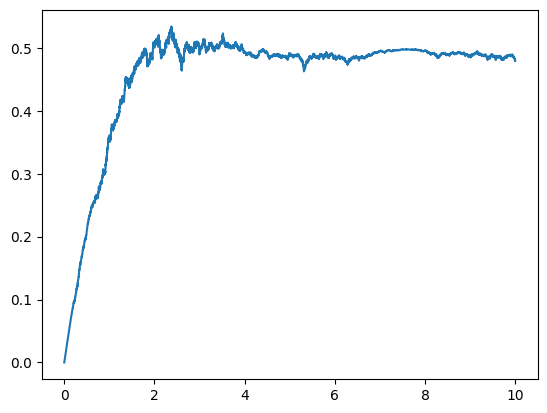

In [69]:
plt.plot(times, photodetection_dfs["++"], label="++")
plt.show()

Options:
-----------
atol:              1e-08
rtol:              1e-06
method:            adams
order:             12
nsteps:            1000
first_step:        0
min_step:          0
max_step:          0
tidy:              True
num_cpus:          4
norm_tol:          0.001
norm_steps:        5
rhs_filename:      None
rhs_reuse:         False
seeds:             0
rhs_with_state:    False
average_expect:    True
average_states:    False
ntraj:             500
store_states:      False
store_final_state: False

        
    #Parametri solver Qutip


    ###STORAGE : FINAL_STATE, STATES, MEASUREMENT, RUNS_RESULTS


        - | store_final_state : bool
          | Whether or not to store the final state of the evolution in the
            result class.



        - | store_states : bool, None
          | Whether or not to store the state vectors or density matrices.
            On `None` the states will be saved if no expectation operators are
            given.



        - | store_measurement: str, {'start', 'middle', 'end', ''}
          | Whether and how to store the measurement for each trajectories.
            'start', 'middle', 'end' indicate when in the interval the
            expectation value of the ``m_ops`` is taken.



        - | keep_runs_results : bool
          | Whether to store results from all trajectories or just store the
            averages.




    ### : FINAL_STATE, STATES, MEASUREMENT, RUNS_RESULTS


        - | normalize_output : bool
          | Normalize output state to hide ODE numerical errors. Only normalize
            the state if the initial state is already normalized.



        - | progress_bar : str {'text', 'enhanced', 'tqdm', ''}
          | How to present the solver progress.
            'tqdm' uses the python module of the same name and raise an error
            if not installed. Empty string or False will disable the bar.


        - | progress_kwargs : dict
          | kwargs to pass to the progress_bar. Qutip's bars use `chunk_size`.



        - | method : str
          | Which stochastic differential equation integration method to use.
            Main ones are {"euler", "rouchon", "platen", "taylor1.5_imp"}



        - | map : str {"serial", "parallel", "loky", "mpi"}
          | How to run the trajectories. "parallel" uses the multiprocessing
            module to run in parallel while "loky" and "mpi" use the "loky" and
            "mpi4py" modules to do so.




        - | num_cpus : NoneType, int
          | Number of cpus to use when running in parallel. ``None`` detect the
            number of available cpus.



        - | dt : float
          | The finite steps lenght for the Stochastic integration method.
            Default change depending on the integrator.

In [ ]:
#Lavorare sul perché |ee> ha spin squeezing = 0

In [3]:
ee

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]

In [18]:
xi_KU_solver(0, ee)

1.0